## Importar y cargar librerias necesarias

En esta parte vamos a importar las librerias esenciales para realizar nuestro proyecto de crear un  modelo de Machine Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo de Graficos

sns.set_theme(style="whitegrid")

# Dataset

df = pd.read_csv('../data/raw/02_bank.csv', sep=',')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## Inspeccion de Valores Nulos

Aca vamor a ispeccionar los valores nulos

In [3]:

# Estadisticas basicas de variables numericas

print("ESTADISTICAS DESCRIPTIVAS")
display(df.describe())

ESTADISTICAS DESCRIPTIVAS


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


/tmp/ipykernel_5961/897310396.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='deposit', palette='Set2')


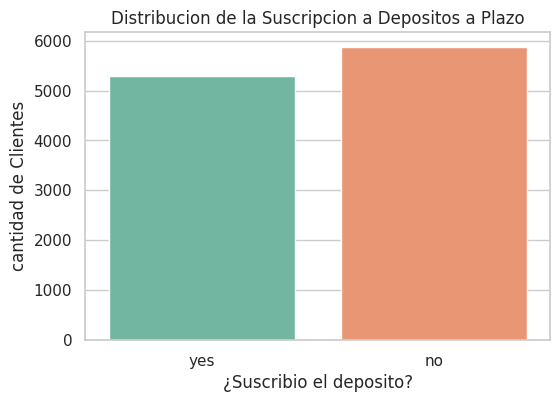

Porcentaje de clientes por categoria:


deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64

In [4]:
# Grafico de acuerdo de cliente

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='deposit', palette='Set2')
plt.title('Distribucion de la Suscripcion a Depositos a Plazo')
plt.xlabel('¿Suscribio el deposito?')
plt.ylabel('cantidad de Clientes')
plt.show()

# Ver el procentaje exacto
porcentajes = df['deposit'].value_counts(normalize=True) * 100
print("Porcentaje de clientes por categoria:")
porcentajes

## Descubriendo patrones

Compararemos datos para ver porque los clientes SI se suscriben y/o prefieren los depositos a plazo

/tmp/ipykernel_5961/312389636.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='deposit', y='age', palette='Set2', showfliers=False)
/tmp/ipykernel_5961/312389636.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='deposit', y='duration', palette='Set2', showfliers=False)


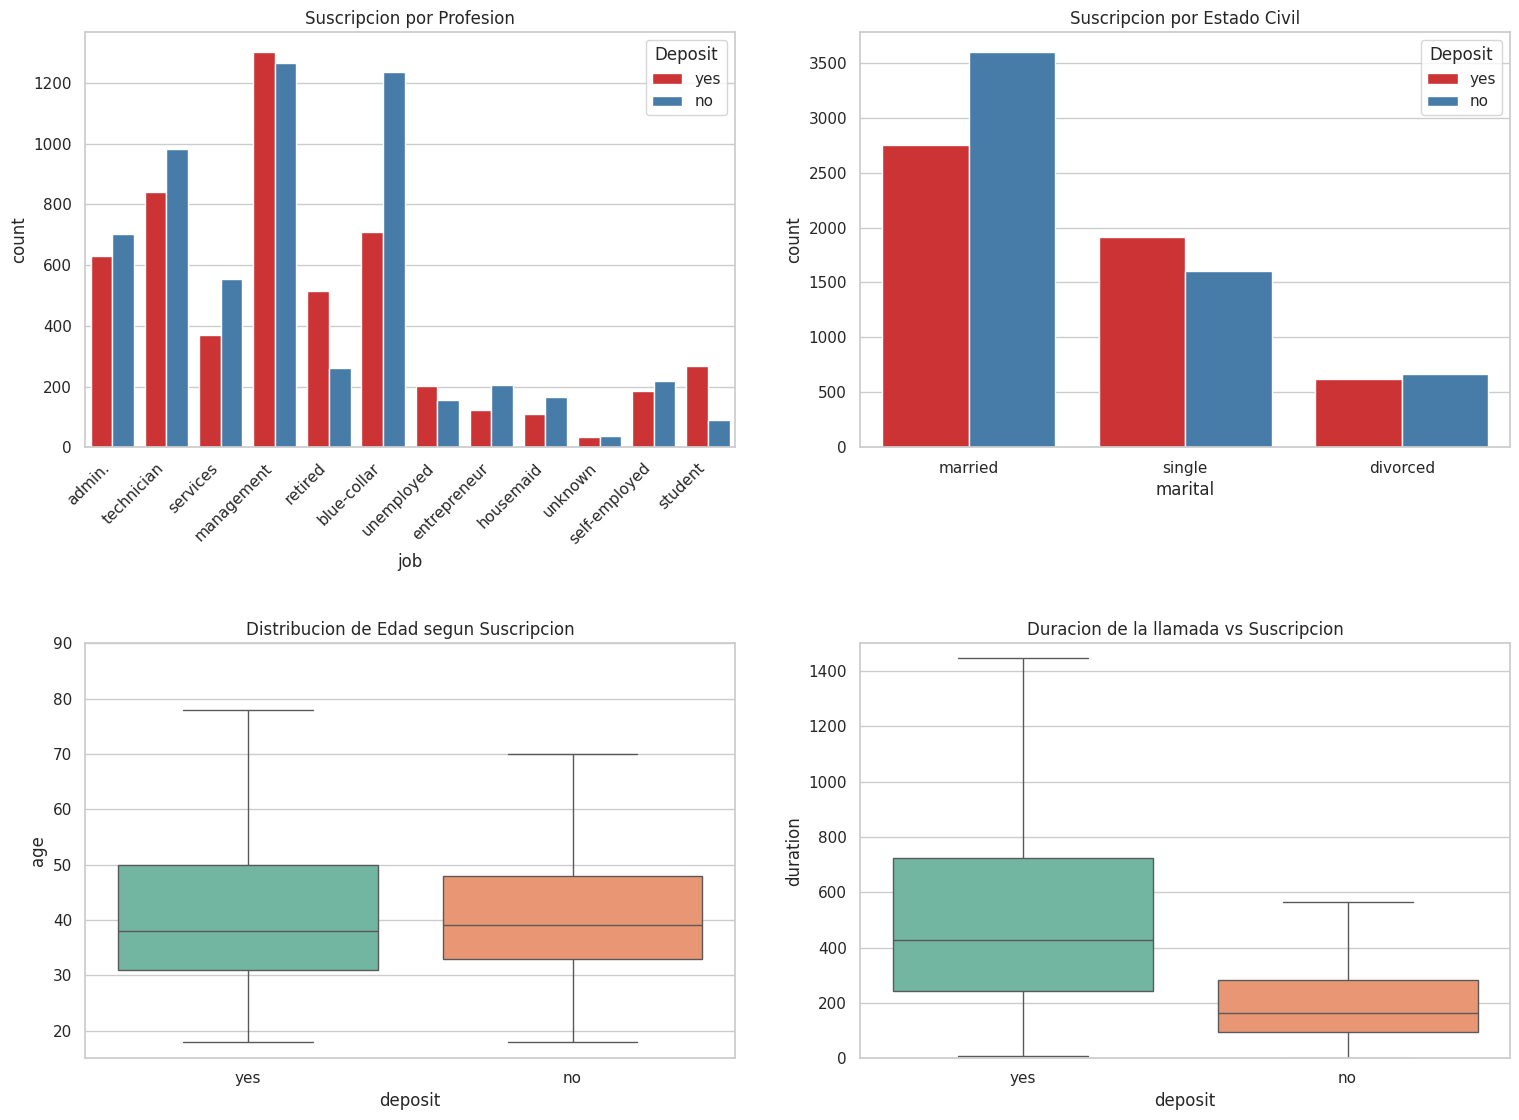

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion visual

sns.set_theme(style = "whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Profesion vs Suscripcion

plt.subplot(2, 2, 1)
sns.countplot(data=df, x='job', hue='deposit', palette='Set1', ax=axes[0,0])
plt.title('Suscripcion por Profesion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Deposit', loc='upper right')

# Estado Civil vs Suscripcion

plt.subplot(2, 2, 2)
sns.countplot(data=df, x='marital', hue='deposit', palette='Set1', ax=axes[0,1])
plt.title('Suscripcion por Estado Civil')
plt.legend(title='Deposit', loc='upper right')

# Edad vs Suscripcion

plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='deposit', y='age', palette='Set2', showfliers=False)
plt.title('Distribucion de Edad segun Suscripcion')
plt.ylim(15, 90)

# Duracion de la llamada vs Suscripcion
plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='deposit', y='duration', palette='Set2', showfliers=False)
axes[1,1].set_title('Duracion de la llamada vs Suscripcion')
plt.ylim(0,1500)

plt.tight_layout(pad=3.0)
plt.show()

## Conversion de datos


En esta seccion convertimos los datos String o Booleanos en datos numericos porque los modelos de machine learning funcionan en el fondo a base de formulas matematicas, si se les pasa un datos string como algun nombre o alguna palabra ocmo yes o no daria error

In [7]:

# Creacion de copia para el csv asi, si se modifica no se pierden los datos originales

df_clean = df.copy()

# COnvertir variables binarias en 1 y 0

columnas_binarias = ['default', 'housing', 'loan', 'deposit']
for col in columnas_binarias:
    df_clean[col] = df_clean[col].map({'yes': 1, 'no': 0})

# Eliminar la columna "Duration" para evitar fugas de informacion

df_clean = df_clean.drop('duration', axis=1)

# Convertir el resto de columnas en columnas numericas

columnas_categoricas = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
df_clean = pd.get_dummies(df_clean, columns = columnas_categoricas, drop_first=True)

# Convertir todos los valores Booleanos True/false que genera pd.get_dummies a numeros

df_clean = df_clean.astype(int)

print(f'El dataset ahora tiene {df_clean.shape[0]} filas y {df_clean.shape[1]} columnas')
display(df_clean.head())

El dataset ahora tiene 11162 filas y 42 columnas


,age,default,balance,housing,loan,day,campaign,pdays,previous,deposit,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,0,2343,1,0,5,1,-1,0,1,...,0,0,0,1,0,0,0,0,0,1
1,56,0,45,0,0,5,1,-1,0,1,...,0,0,0,1,0,0,0,0,0,1
2,41,0,1270,1,0,5,1,-1,0,1,...,0,0,0,1,0,0,0,0,0,1
3,55,0,2476,1,0,5,1,-1,0,1,...,0,0,0,1,0,0,0,0,0,1
4,54,0,184,0,0,5,2,-1,0,1,...,0,0,0,1,0,0,0,0,0,1


In [12]:
# Guardado del dataset limpio y listo para el modelo de machine learning

import os
import pandas as pd

output_dir = '../data/processed/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f'Carpeta creada automaticamente en: {output_dir}')

df_clean.to_csv(os.path.join(output_dir, '02_bank_cleaned.csv'), index=False)
print("Datos guardados con exito")

Carpeta creada automaticamente en: ../data/processed/
Datos guardados con exito


## Dividir los datos y entrenar el modelo de Machine Learning

En esta seccion vamos a dividir los datos de nuestra tabla en dos partes

1. Datos de entrenamiento: Usaremos alrededor del 80% de los clientes para que el modelo aprenda patrones

2. Datos de prueba: Guardaremos el 20% restante para hacerle un "Examen final" y ver que tan bien hace predicciones


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Separacion de caracteristicas X de la variable objetivo Y

# X sera toda la tabla excepto la columna deposit

X = df_clean.drop('deposit', axis=1)

# Y sera unicamente la columna deposit

y = df_clean['deposit']

# Dividir porcion de entrenamiento (80%) y la porcion de Prueba (20%)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f'Entrenaremos con {X_train.shape[0]} clientes y probaremos con {X_test.shape[0]} clientes')

# Crear el modelo de Machine Learning

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el modelo

print('Entrenando modelo...')
modelo_rf.fit(X_train, y_train)

# Hacer un examen final con los datos de prueba

predicciones = modelo_rf.predict(X_test)

# Evaluar que tan bien se hizo el examen

Precision = accuracy_score(y_test, predicciones)
print(f'Entrenamiento terminado')
print(f'Precision general: {Precision * 100:.2f}%')
print(f'\nReporte detallado:')
print(classification_report(y_test, predicciones))


Entrenaremos con 8929 clientes y probaremos con 2233 clientes
Entrenando modelo...
Entrenamiento terminado
Precision general: 74.25%

Reporte detallado:
              precision    recall  f1-score   support

           0       0.72      0.82      0.77      1166
           1       0.77      0.66      0.71      1067

    accuracy                           0.74      2233
   macro avg       0.75      0.74      0.74      2233
weighted avg       0.75      0.74      0.74      2233



## Definir la Importancia de las variables

En esta parte vamos a responder la siguiente pregunta

Que caracteristicas son las que mas influyen para que un cliente diga que si?


/tmp/ipykernel_5961/669948864.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias_clave, x='Importancia', y='Variable', palette='viridis')


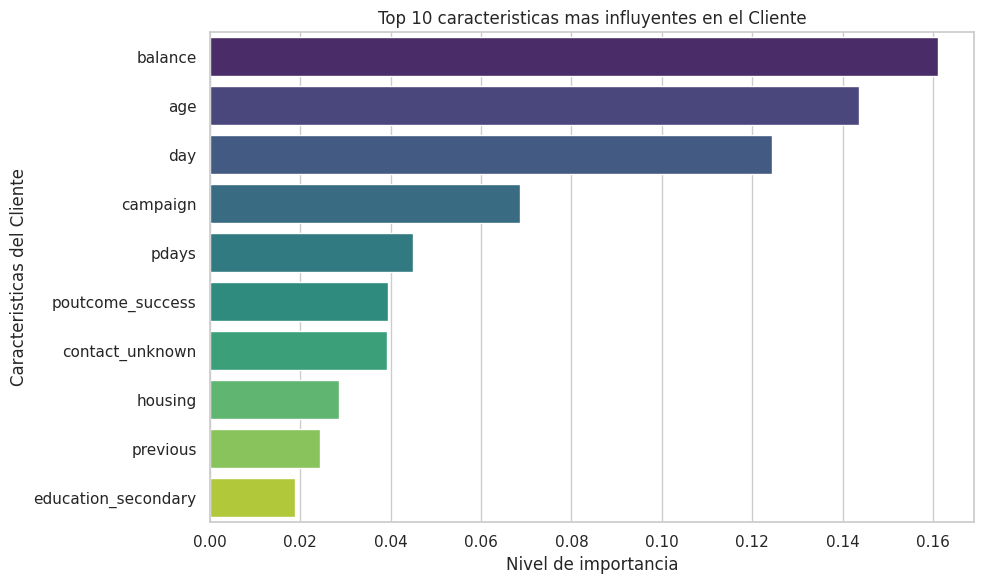

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extraer la importancia de las variables del modelo ya entrenado

importancias = modelo_rf.feature_importances_
nombres_columnas = X_train.columns

# Crear DataFrame ordenado para ver los datos masimportantes arriba

df_importancias = pd.DataFrame({'Variable': nombres_columnas, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by = 'Importancia', ascending=False)

# Quedarse solo con 10 para hacer un grafico entendible

importancias_clave = df_importancias.head(10)

# Graficar resultados

plt.figure(figsize=(10,6))
sns.barplot(data=importancias_clave, x='Importancia', y='Variable', palette='viridis')
plt.title('Top 10 caracteristicas mas influyentes en el Cliente')
plt.xlabel('Nivel de importancia')
plt.ylabel('Caracteristicas del Cliente')
plt.tight_layout()
plt.show()
